# EB Dataset — Functional KL Divergence Estimation

This notebook runs the **Embryoid Body (EB)** benchmark experiment.

It estimates KL divergence between trajectory distributions using Functional Flow Matching (FFM) with the MINO-T architecture. The reference method is **sbirr** and it is compared against: am, mfl, msbm, tigon, vsb.

**Pipeline:** Load trajectories → Train FFM (flow matching in function space) → Estimate KL divergence via Fourier basis projection

**Data shape:** 300 samples × 101 timesteps × 5 dimensions

In [9]:
# imports
import os, sys
import numpy as np

# Repo root is FKL/
REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from util.util import *
from util.plot import *

In [10]:
# ── Configuration ────────────────────────────────────────────────────────────
GPU = "5"                        # CUDA device to use
REF = "sbirr"                    # reference method 
METHODS = ["vsb", "msbm", "mfl", "am", "tigon"]  # methods to compare against

# Move to repo root so relative paths work
os.chdir(REPO_ROOT)
print("Working directory:", os.getcwd())

# Paths (relative to repo root)
SCRIPTS_DIR = "scripts"
CONFIG      = "configs/eb.yaml"
DATA_DIR    = "data/EB"
LOG_DIR     = "log/EB"

M = 101  # grid size (must match config)

Working directory: /home/nepote/FKL_Chao/FKL


## Visualization

In [11]:
irr = np.load("data/EB/sbirr.npy")
tigon = np.load("data/EB/tigon.npy")
mfl = np.load("data/EB/mfl.npy")
am = np.load("data/EB/am.npy")
vsb = np.load("data/EB/vsb.npy")
msbm = np.load("data/EB/msbm.npy")

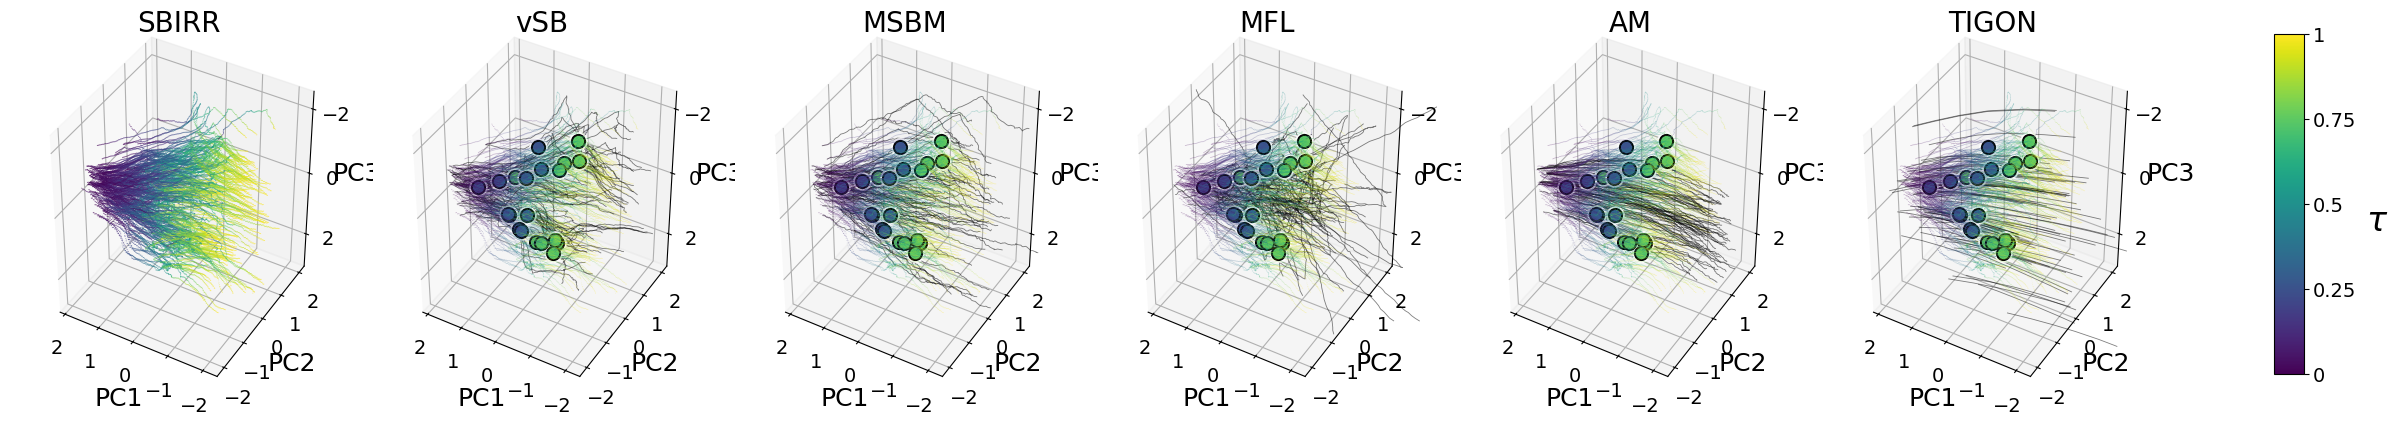

In [12]:
# ----------------------------
# GLOBAL FONT SIZES
# ----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

fig = plt.figure(figsize=(25, 5))

methods = {
    "SBIRR":       irr,        
    "vSB":         vsb,
    "MSBM":        msbm,
    "MFL":         mfl,
    "AM":          am,
    "TIGON":       tigon,
}

# -----------------------
# COUNTS / VISIBILITY
# -----------------------
N_REF_SHOW = 250
N_LINES    = 80

REF_ALPHA = 0.30
REF_LW    = 0.5

FG_ALPHA  = 0.50
FG_LW     = 0.6

# --- validation points on SBIRR ---
VAL_TAU    = np.array([0.25, 0.75], dtype=float)
N_VAL_PTS  = 10

# make points very visible
PTS_S       = 90
PTS_EDGE_LW = 1.4
HALO_S      = 180
HALO_ALPHA  = 0.95

methods = {k: first3(v, k) for k, v in methods.items()}

# -----------------------
# Axis limits computed from SBIRR reference
# -----------------------
sbirr_arr = methods["SBIRR"]
pts_ref = sbirr_arr.reshape(-1, 3)

x_min, x_max = pts_ref[:, 0].min(), pts_ref[:, 0].max()
y_min, y_max = pts_ref[:, 1].min(), pts_ref[:, 1].max()
z_min, z_max = pts_ref[:, 2].min(), pts_ref[:, 2].max()

pad = 0.05
x_pad = pad * (x_max - x_min)
y_pad = pad * (y_max - y_min)
z_pad = pad * (z_max - z_min)
x_min, x_max = x_min - x_pad, x_max + x_pad
y_min, y_max = y_min - y_pad, y_max + y_pad
z_min, z_max = z_min - z_pad, z_max + z_pad

# -----------------------
# Colormap
# -----------------------
cmap = plt.get_cmap("viridis")
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# -----------------------
# Indices to draw (fixed for comparability)
# -----------------------
rng_ref = np.random.default_rng(123)
rng_fg  = np.random.default_rng(12)
rng_val = np.random.default_rng(202)

N_ref = sbirr_arr.shape[0]
n_ref_show = min(N_REF_SHOW, N_ref)
idx_ref = rng_ref.choice(N_ref, size=n_ref_show, replace=False) if N_ref > n_ref_show else np.arange(n_ref_show)

N_REF_SHOW_SBIRR_PANEL = 300
n_ref_show_sbirr = min(N_REF_SHOW_SBIRR_PANEL, N_ref)
idx_ref_sbirr = rng_ref.choice(N_ref, size=n_ref_show_sbirr, replace=False) if N_ref > n_ref_show_sbirr else np.arange(n_ref_show_sbirr)

n_val = min(N_VAL_PTS, len(idx_ref))
idx_val_traj = rng_val.choice(idx_ref, size=n_val, replace=False) if len(idx_ref) > n_val else np.asarray(idx_ref)

# -----------------------
# PLOTTING
# -----------------------
for i, (name, arr) in enumerate(methods.items(), 1):
    ax = fig.add_subplot(1, len(methods), i, projection="3d")

    idx_ref_use = idx_ref_sbirr if name == "SBIRR" else idx_ref

    # SBIRR colored reference under everything
    add_colored_trajectories_3d(ax, sbirr_arr, idx_ref_use, cmap=cmap, norm=norm,
                                alpha=REF_ALPHA, lw=REF_LW)

    # black method trajectories on top (except SBIRR itself)
    if name != "SBIRR":
        plot_black_trajectories(ax, arr, n_traj=min(N_LINES, arr.shape[0]),
                                alpha=FG_ALPHA, lw=FG_LW, rng=rng_fg)
    else:
        add_colored_trajectories_3d(ax, sbirr_arr, idx_ref_use, cmap=cmap, norm=norm,
                                    alpha=min(0.80, REF_ALPHA + 0.20),
                                    lw=REF_LW + 0.2)

    if name != "SBIRR":
        scatter_sbirr_points_at_taus_3d(ax, sbirr_arr, VAL_TAU, idx_traj=idx_val_traj,
                                        cmap=cmap, norm=norm,
                                        pts_s=PTS_S, pts_edge_lw=PTS_EDGE_LW,
                                        halo_s=HALO_S, halo_alpha=HALO_ALPHA)

    ax.set_title(name, fontsize=20)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.view_init(-140, 60)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect((x_max - x_min, y_max - y_min, z_max - z_min))

# -----------------------
# Layout + colorbar
# -----------------------
plt.tight_layout(rect=[0, 0, 0.88, 1])

cax = fig.add_axes([0.915, 0.17, 0.012, 0.68])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("$\\tau$", fontsize=24, rotation=0, labelpad=15)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0", "0.25", "0.5", "0.75", "1"])
plt.show()

## Single method run

Run sbirr vs **vsb**. Change `methodB` to run a different comparison.

In [13]:
methodB = "tigon"
!cd {SCRIPTS_DIR} && \
  CUDA_VISIBLE_DEVICES={GPU} python main.py \
    -c ../{CONFIG} \
    --set data_params.X1.A_path.{M}=../{DATA_DIR}/{REF}.npy \
    --set data_params.X1.B_path.{M}=../{DATA_DIR}/{methodB}.npy \
    --set trainer_params.sfolder=../{LOG_DIR}/{REF}_{methodB}

/home/nepote/miniconda/envs/FFM_muon/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /home/nepote/miniconda/envs/FFM_muon/lib/python3.11/site-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
data_params:
  general:
    M: 101
    D: 5
    amp_way: '*knrm'
    x0source: gt
  X0_GP_matern:
    noise_type: data
    n_empirical: 32
    eps_decay: 1.0
    nu_K: 0.5
    ell_K: 0.1
    sigma2_K: 1.0
    white_noise: false
  X1:
    A_path:
      101: ../data/EB/sbirr.npy
    B_path:
      101: ../data/EB/tigon.npy
trainer_params:
  n_samples_train: 300
  n_samples_gen: 150
  t_train_sampling_scheme: importance_sampling_t/(1-t)
  prediction: vt_from_substraction
  loss_lam_time: 1
  loss_decay: true
  batch_size: 32
  num_iterations: 20000
  ema_opti: true
  sfolder: ../log/EB/sbirr_tigon
  upsample_gen:
  - 1
  epochs_selected: -1
  l

## Batch run — all methods

Runs sbirr vs each method sequentially. Each comparison trains a separate model and estimates KL.

In [ ]:
import subprocess

for methodB in METHODS:
    print(f"\n{'='*60}")
    print(f"  Running: {REF} vs {methodB}")
    print(f"{'='*60}\n")

    cmd = (
        f"cd {SCRIPTS_DIR} && "
        f"CUDA_VISIBLE_DEVICES={GPU} python main.py "
        f"-c ../{CONFIG} "
        f"--set data_params.X1.A_path.{M}=../{DATA_DIR}/{REF}.npy "
        f"--set data_params.X1.B_path.{M}=../{DATA_DIR}/{methodB}.npy "
        f"--set trainer_params.sfolder=../{LOG_DIR}/{REF}_{methodB}"
    )

    result = subprocess.run(cmd, shell=True, capture_output=False)
    if result.returncode != 0:
        print(f"WARNING: {REF} vs {methodB} exited with code {result.returncode}")

print("\nAll runs finished.")

## Inspect results

Load the output config files which contain the estimated KL divergence values.

In [ ]:
import yaml
from pathlib import Path
import glob

print(f"{'Method':<12} {'Forward KL':>12} {'Reverse KL':>12}")
print("-" * 40)

for methodB in METHODS:
    run_dir = Path(LOG_DIR) / f"{REF}_{methodB}"
    # Find the final KL result file
    result_files = sorted(run_dir.glob("config_kl_FINAL_*.yaml"))
    if not result_files:
        print(f"{methodB:<12} {'(not found)':>12} {'':>12}")
        continue

    with open(result_files[-1], "r") as f:
        cfg = yaml.safe_load(f)

    kl = cfg.get("kl_result", {}).get(1, {})
    fwd = kl.get("forward_KL", "N/A")
    rev = kl.get("reverse_KL", "N/A")

    fwd_str = f"{fwd:.4f}" if isinstance(fwd, (int, float)) else str(fwd)
    rev_str = f"{rev:.4f}" if isinstance(rev, (int, float)) else str(rev)
    print(f"{methodB:<12} {fwd_str:>12} {rev_str:>12}")

## View generated trajectory plots

Display the generated vs real trajectory PDFs for a specific method.

In [ ]:
from IPython.display import display, Image
from pathlib import Path

methodB = "vsb"  # change to view other methods
run_dir = Path(LOG_DIR) / f"{REF}_{methodB}" / "imgs"

for pdf in sorted(run_dir.glob("*.pdf")):
    print(f"\n{pdf.name}")
    display(Image(filename=str(pdf)))